In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False



In [2]:
# =====================================================
# 1️⃣ 데이터 로드
# =====================================================
csv_path = "new_flight_weather_merged.csv"
df = pd.read_csv(csv_path)

print("✅ CSV 로드 완료")
print("전체 행 수:", len(df))

C:\Users\Admin\AppData\Local\Temp\ipykernel_4420\729722976.py:5: DtypeWarning: Columns (31,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✅ CSV 로드 완료
전체 행 수: 2836872


In [3]:
# =====================================================
# 2️⃣ 상태 == '지연' 데이터만 사용
# -----------------------------------------------------
# ✔ 지연시간 회귀는 '지연이 발생한 항공편'만 의미가 있음
# ✔ 정상/결항/회항 데이터는 회귀 대상이 아님
# =====================================================
reg_df = df[df["상태"] == "지연"].copy()
print("⏱ 상태=지연 데이터 수:", len(reg_df))

⏱ 상태=지연 데이터 수: 480982


In [4]:
# =====================================================
# 3️⃣ 지연_분 분포 확인 (정제 전)
# -----------------------------------------------------
# ✔ 데이터 이상치/결측치 여부 파악 목적
# =====================================================
print("📊 정제 전 지연_분 분포")
print(reg_df["지연_분"].describe())

📊 정제 전 지연_분 분포
count    480982.000000
mean         57.602601
std          42.985101
min       -1414.000000
25%          36.000000
50%          46.000000
75%          64.000000
max        1391.000000
Name: 지연_분, dtype: float64


In [5]:
# =====================================================
# 4️⃣ 지연_분 정제
# -----------------------------------------------------
# ✔ y(target)에 NaN이 있으면 모델 학습 불가
# ✔ 음수 지연은 논리적으로 불가능
# =====================================================

# ❗ 지연_분 NaN 제거 (가장 중요)
reg_df = reg_df[reg_df["지연_분"].notna()]

# ❗ 음수 제거
reg_df = reg_df[reg_df["지연_분"] >= 0].copy()

print("📊 음수 + NaN 제거 후 지연_분 분포")
print(reg_df["지연_분"].describe())

📊 음수 + NaN 제거 후 지연_분 분포
count    480517.000000
mean         57.753488
std          41.523529
min           0.000000
25%          36.000000
50%          46.000000
75%          65.000000
max        1391.000000
Name: 지연_분, dtype: float64


In [6]:
# =====================================================
# 5️⃣ 지연시간 상한 컷
# -----------------------------------------------------
# ✔ 360분(6시간) 이상은 이벤트성 지연
# ✔ 회귀 모델 안정화를 위해 상한 적용
# =====================================================
MAX_DELAY = 360
reg_df = reg_df[reg_df["지연_분"] <= MAX_DELAY].copy()

print("📊 상한 컷 후 지연_분 분포")
print(reg_df["지연_분"].describe())


📊 상한 컷 후 지연_분 분포
count    479429.000000
mean         56.744999
std          34.943600
min           0.000000
25%          36.000000
50%          46.000000
75%          64.000000
max         360.000000
Name: 지연_분, dtype: float64


In [7]:
# =====================================================
# 6️⃣ Feature 정의 (도착지 -> arrival_code, cat_cols 변경)
# =====================================================

# ✅ 도착지 -> arrival_code 생성 (cat으로 쓸 거라 str로 고정)
if "도착지" in reg_df.columns:
    tmp = pd.to_numeric(reg_df["도착지"], errors="coerce")

    # 도착지가 숫자형이면 숫자 변환 성공률이 높음
    if tmp.notna().mean() > 0.7:
        reg_df["arrival_code"] = tmp.fillna(-1).astype(int).astype(str)
    else:
        # 도착지가 문자형(예: ICN/GMP)이면 category.codes로 코드화
        reg_df["arrival_code"] = (
            reg_df["도착지"].astype("category").cat.codes.astype(int).astype(str)
        )
else:
    # 도착지가 없으면 안전장치
    reg_df["arrival_code"] = "-1"


# 🔢 수치형 변수
num_cols = [
    "기온(°C)",
    "풍속_ms",
    "dep_hour",
    "dep_weekday",
    "is_weekend"
]

# 🏷 범주형 변수 (✅ 도착지 제거, arrival_code 추가)
cat_cols = [
    "항공사",
    "출발지",
    "flight_type",
    "arrival_code"
]

# 실제 존재하는 컬럼만 사용
num_cols = [c for c in num_cols if c in reg_df.columns]
cat_cols = [c for c in cat_cols if c in reg_df.columns]

X_cols = num_cols + cat_cols

print("✅ num_cols:", num_cols)
print("✅ cat_cols:", cat_cols)
print("✅ X_cols:", X_cols)


✅ num_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend']
✅ cat_cols: ['항공사', '출발지', 'flight_type', 'arrival_code']
✅ X_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend', '항공사', '출발지', 'flight_type', 'arrival_code']


In [8]:
# =====================================================
# 7️⃣ 시간 기준 Train / Test 분리
# -----------------------------------------------------
# ✔ 미래 정보 누수 방지
# ✔ 실제 운영 상황과 동일한 분리 방식
# =====================================================
reg_df["departure_datetime"] = pd.to_datetime(reg_df["departure_datetime"], errors="coerce")
reg_df = reg_df[reg_df["departure_datetime"].notna()].copy()

split_date = reg_df["departure_datetime"].quantile(0.8)

train_df = reg_df[reg_df["departure_datetime"] <= split_date]
test_df  = reg_df[reg_df["departure_datetime"] > split_date]

X_train = train_df[X_cols]
y_train = train_df["지연_분"]

X_test  = test_df[X_cols]
y_test  = test_df["지연_분"]

print("Train:", len(X_train), "Test:", len(X_test))

Train: 383544 Test: 95885


In [9]:
# =====================================================
# 8️⃣ y(target) NaN 사전 점검 및 제거
# -----------------------------------------------------
# ✔ y에 NaN이 있으면 모델 학습 불가
# ✔ X와 y를 동시에 정제하여 인덱스 불일치 방지
# =====================================================
print("y_train NaN 수:", y_train.isna().sum())
print("y_test  NaN 수:", y_test.isna().sum())

train_mask = y_train.notna()
test_mask  = y_test.notna()

X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test  = X_test.loc[test_mask]
y_test  = y_test.loc[test_mask]

print("NaN 제거 후 Train:", len(X_train), "Test:", len(X_test))

y_train NaN 수: 0
y_test  NaN 수: 0
NaN 제거 후 Train: 383544 Test: 95885


In [10]:
# =====================================================
# 9️⃣ 전처리 파이프라인
# -----------------------------------------------------
# ✔ 수치형: 중앙값 대치
# ✔ 범주형: UNKNOWN + One-Hot Encoding
# =====================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


In [11]:
# =====================================================
# 🔟 Linear Regression (Baseline)
# -----------------------------------------------------
# ✔ 가장 단순한 기준 모델
# =====================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lin_reg = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print("📊 Linear Regression")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


📊 Linear Regression
MAE : 22.111737858317728
RMSE: 30.96564860764025


In [12]:
# =====================================================
# 1️⃣1️⃣ Ridge Regression
# -----------------------------------------------------
# ✔ 다중공선성 완화
# ✔ 선형 모델 중 가장 안정적
# =====================================================
from sklearn.linear_model import Ridge

ridge_reg = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

ridge_reg.fit(X_train, y_train)
y_pred = ridge_reg.predict(X_test)

print("📊 Ridge Regression")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

📊 Ridge Regression
MAE : 22.108196468979223
RMSE: 30.961419146231812


In [13]:
# =====================================================
# 1️⃣2️⃣ Log-Ridge Regression
# -----------------------------------------------------
# ✔ 지연시간의 long-tail 분포 대응
# ✔ 실제 성능 개선 효과 큼
# =====================================================
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

ridge_reg.fit(X_train, y_train_log)

y_pred_log = ridge_reg.predict(X_test)
y_pred = np.expm1(y_pred_log)

print("📊 Log-Ridge Regression")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

📊 Log-Ridge Regression
MAE : 19.245604923293996
RMSE: 30.05827492569831


In [14]:
# =====================================================
# 1️⃣3️⃣ 예측 결과 확인
# =====================================================
result_df = pd.DataFrame({
    "actual_delay": y_test.values,
    "predicted_delay": y_pred
})

result_df.head(20)

,actual_delay,predicted_delay
0,71.0,64.136286
1,79.0,44.040804
2,95.0,66.127656
3,47.0,47.105715
4,154.0,72.588751
5,216.0,55.632226
6,91.0,62.153067
7,63.0,64.727665
8,29.0,47.214763
9,85.0,66.643371


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1037
[LightGBM] [Info] Number of data points in the train set: 383544, number of used features: 317
[LightGBM] [Info] Start training from score 57.365679


C:\Users\Admin\anaconda3\envs\4vector\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002017 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1037
[LightGBM] [Info] Number of data points in the train set: 383544, number of used features: 317
[LightGBM] [Info] Start training from score 3.945627


C:\Users\Admin\anaconda3\envs\4vector\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ LightGBM 최종 선택: Log Target


,모델,MAE (분),RMSE (분)
0,LightGBM,17.758442,28.156206
1,Log-Ridge Regression,19.245605,30.058275
2,Ridge Regression,22.108196,30.961419
3,Linear Regression,22.111738,30.965649


✅ best model = LightGBM


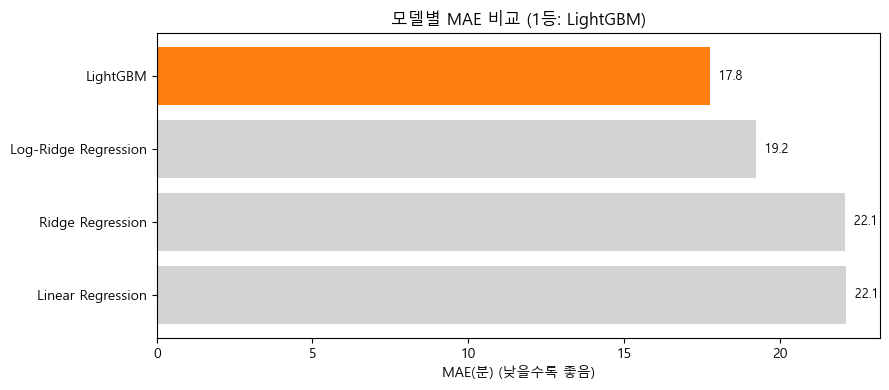

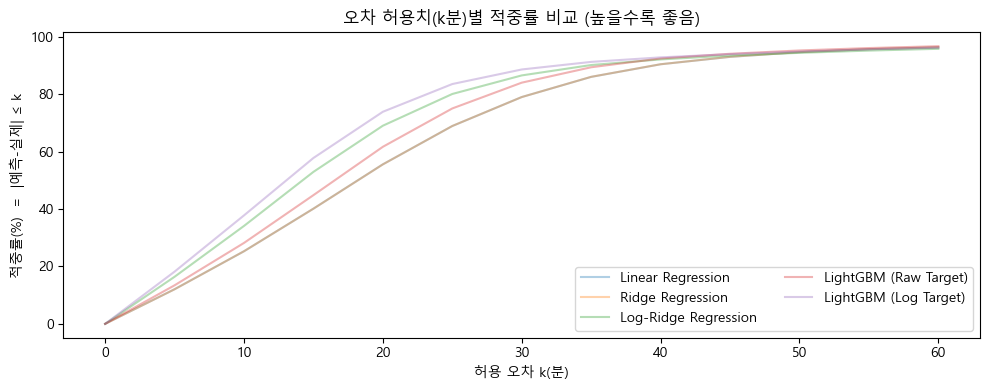

In [16]:
# =====================================================
# ✅ 모델 학습/평가/비교 (변수 덮어쓰기 방지 버전)
# - Linear / Ridge / Log-Ridge / LightGBM Raw / LightGBM Log
# - summary_df, preds 생성
# - LightGBM이 제일 잘 맞는 걸 보여주는 비교 시각화 3종 포함
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

# ✅ 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# =====================================================
# 1) 모델 정의
# =====================================================

lin_reg = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

ridge_reg = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

lgbm_reg = Pipeline([
    ("prep", preprocessor),
    ("reg", LGBMRegressor(
        objective="regression",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# =====================================================
# 2) 학습 + 예측 (✅ 변수명 분리)
# =====================================================

# (1) Linear
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# (2) Ridge
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

# (3) Log-Ridge
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

ridge_reg.fit(X_train, y_train_log)
y_pred_log_ridge_log = ridge_reg.predict(X_test)     # log-space 예측
y_pred_log_ridge = np.expm1(y_pred_log_ridge_log)    # 분 단위로 원복

# (4) LightGBM Raw
lgbm_reg.fit(X_train, y_train)
y_pred_lgbm_raw = lgbm_reg.predict(X_test)

# (5) LightGBM Log Target
lgbm_reg.fit(X_train, y_train_log)
y_pred_lgbm_logspace = lgbm_reg.predict(X_test)
y_pred_lgbm_log = np.expm1(y_pred_lgbm_logspace)     # 분 단위 원복



# =====================================================
# ✅ LightGBM Raw vs Log 중 MAE 기준으로 하나만 선택
# =====================================================

mae_lgbm_raw = mean_absolute_error(y_test, y_pred_lgbm_raw)
mae_lgbm_log = mean_absolute_error(y_test, y_pred_lgbm_log)

if mae_lgbm_log <= mae_lgbm_raw:
    y_pred_lgbm_final = y_pred_lgbm_log
    print("✅ LightGBM 최종 선택: Log Target")
else:
    y_pred_lgbm_final = y_pred_lgbm_raw
    print("✅ LightGBM 최종 선택: Raw Target")
    
# =====================================================
# 3) 성능 요약표 (summary_df)
# =====================================================

summary_df = pd.DataFrame({
    "모델": [
        "Linear Regression",
        "Ridge Regression",
        "Log-Ridge Regression",
        "LightGBM"
    ],
    "MAE (분)": [
        mean_absolute_error(y_test, y_pred_lin),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_log_ridge),
        mean_absolute_error(y_test, y_pred_lgbm_final)
    ],
    "RMSE (분)": [
        RMSE(y_test, y_pred_lin),
        RMSE(y_test, y_pred_ridge),
        RMSE(y_test, y_pred_log_ridge),
        RMSE(y_test, y_pred_lgbm_final)
    ]
}).sort_values("MAE (분)").reset_index(drop=True)

display(summary_df)



# =====================================================
# 4) 모델별 예측값 모음 (preds)  ✅ 여기서부터 비교 시각화 가능
# =====================================================

preds = {
    "Linear Regression": y_pred_lin,
    "Ridge Regression": y_pred_ridge,
    "Log-Ridge Regression": y_pred_log_ridge,
    "LightGBM (Raw Target)": y_pred_lgbm_raw,
    "LightGBM (Log Target)": y_pred_lgbm_log
}

best_name = summary_df.loc[0, "모델"]

print("✅ best model =", best_name)

# =====================================================
# 5) (시각화 1) 모델 랭킹 막대: MAE (베스트 모델만 강조)
# =====================================================

colors = ["tab:orange" if m == best_name else "lightgray" for m in summary_df["모델"]]

plt.figure(figsize=(9,4))
plt.barh(summary_df["모델"], summary_df["MAE (분)"], color=colors)
plt.gca().invert_yaxis()
plt.title(f"모델별 MAE 비교 (1등: {best_name})")
plt.xlabel("MAE(분) (낮을수록 좋음)")
for i, v in enumerate(summary_df["MAE (분)"]):
    plt.text(v, i, f"  {v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


    
# =====================================================
# 6) (시각화 2) 오차 허용치별 적중률(Accuracy@k): |오차| ≤ k
#    -> PPT에서 “LightGBM이 더 자주 맞춘다”를 제일 직관적으로 보여줌
# =====================================================

y_true = np.asarray(y_test)
thresholds = np.arange(0, 61, 5)  # 0~60분 (원하면 120까지 늘리기)

plt.figure(figsize=(10,4))
for name, p in preds.items():
    p = np.asarray(p)
    abs_err = np.abs(p - y_true)
    acc = [(abs_err <= t).mean() * 100 for t in thresholds]

    if name == best_name:
        plt.plot(thresholds, acc, marker="o", linewidth=3, label=f"{name} (베스트)")
    else:
        plt.plot(thresholds, acc, alpha=0.35, label=name)

plt.title("오차 허용치(k분)별 적중률 비교 (높을수록 좋음)")
plt.xlabel("허용 오차 k(분)")
plt.ylabel("적중률(%)  =  |예측-실제| ≤ k")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# =====================================================
# 7) (시각화 3) 지연 구간별 MAE: 긴 지연에서도 누가 덜 무너지는지
# =====================


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 필수 체크
for v in ["preds", "summary_df", "y_test"]:
    if v not in globals():
        raise NameError(f"❌ 먼저 '{v}' 변수를 만드는 셀을 실행해야 합니다.")

y_true = np.asarray(y_test)

# =========================================================
# 1) 모델 랭킹 막대그래프 (베스트 모델 하이라이트)
# =========================================================
best_name = summary_df.loc[0, "모델"]
best_mae  = summary_df.loc[0, "MAE (분)"]

colors = ["tab:orange" if m == best_name else "lightgray" for m in summary_df["모델"]]

plt.figure(figsize=(9,4))
plt.barh(summary_df["모델"], summary_df["MAE (분)"], color=colors)
plt.gca().invert_yaxis()
plt.title(f"모델별 MAE 비교 (1등: {best_name})")
plt.xlabel("MAE(분) (낮을수록 좋음)")
for i, v in enumerate(summary_df["MAE (분)"]):
    plt.text(v, i, f"  {v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# (선택) 2등 대비 개선율 텍스트 출력
if len(summary_df) >= 2:
    second_mae = summary_df.loc[1, "MAE (분)"]
    improve = (second_mae - best_mae) / second_mae * 100
    print(f"✅ 2등 대비 MAE 개선율: {improve:.2f}%  ( {second_mae:.2f} → {best_mae:.2f} )")


# =========================================================
# 2) 오차 허용치별 적중률 곡선 (Accuracy@k분)
#    -> 'k분 이내로 맞춘 비율'을 모델별로 비교 (PPT에서 매우 직관적)
# =========================================================
thresholds = np.arange(0, 61, 5)  # 0~60분, 5분 간격 (원하면 120까지 늘려도 됨)

plt.figure(figsize=(10,4))
for name, pred in preds.items():
    pred = np.asarray(pred)
    abs_err = np.abs(pred - y_true)

    acc = [(abs_err <= t).mean() * 100 for t in thresholds]  # 퍼센트(%)
    if name == best_name:
        plt.plot(thresholds, acc, marker="o", linewidth=3, label=f"{name} (베스트)")
    else:
        plt.plot(thresholds, acc, alpha=0.35, label=name)

plt.title("오차 허용치(k분)별 적중률 비교 (높을수록 좋음)")
plt.xlabel("허용 오차 k (분)")
plt.ylabel("적중률(%) = |예측-실제| ≤ k")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


# =========================================================
# 3) 지연 구간별 MAE - 모든 모델 비교 (긴 지연에서 누가 버티는지)
# =========================================================
bins = [0, 30, 60, 120, 240, 360]
labels = ["0~30", "30~60", "60~120", "120~240", "240~360"]

bucket = pd.DataFrame({"actual": y_true})
bucket["구간"] = pd.cut(bucket["actual"], bins=bins, labels=labels, include_lowest=True)

def mae(a, p):
    return np.mean(np.abs(np.asarray(p) - np.asarray(a)))

bucket_mae_all = {}
for name, pred in preds.items():
    pred = np.asarray(pred)
    tmp = bucket.copy()
    tmp["pred"] = pred
    bucket_mae_all[name] = tmp.groupby("구간").apply(lambda x: mae(x["actual"], x["pred"]))

bucket_mae_df = pd.DataFrame(bucket_mae_all)

plt.figure(figsize=(10,4))
for name in bucket_mae_df.columns:
    if name == best_name:
        plt.plot(bucket_mae_df.index.astype(str), bucket_mae_df[name].values, marker="o", linewidth=3, label=f"{name} (베스트)")
    else:
        plt.plot(bucket_mae_df.index.astype(str), bucket_mae_df[name].values, alpha=0.35, label=name)

plt.title("지연 구간별 MAE 모델 비교 (낮을수록 좋음)")
plt.xlabel("실제 지연 구간(분)")
plt.ylabel("MAE(분)")
plt.legend(ncol=2)
plt.tight_layout()

plt.show()
